In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print(np.__version__)
print(pd.__version__)

2.5.1
3.0.5


In [2]:
data=pd.read_csv("lab2_machines.csv")
data.head()

,machine_type,runtime_hours,temperature,vibration,pressure,needs_service
0,lathe,1837.7,60.23,1.61,3.96,0
1,lathe,560.1,90.55,3.96,3.12,1
2,press,551.5,65.58,1.29,5.04,0
3,drill,968.6,71.60,2.87,4.30,0
4,lathe,2688.5,72.06,2.30,4.68,0


In [3]:
data.shape

(300, 6)

In [4]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   machine_type   300 non-null    str    
 1   runtime_hours  300 non-null    float64
 2   temperature    270 non-null    float64
 3   vibration      277 non-null    float64
 4   pressure       284 non-null    float64
 5   needs_service  300 non-null    int64  
dtypes: float64(4), int64(1), str(1)
memory usage: 14.2 KB


In [5]:
data.describe()

,runtime_hours,temperature,vibration,pressure,needs_service
count,300.000000,270.000000,277.000000,284.000000,300.000000
mean,2077.605667,69.733852,2.237365,3.797711,0.206667
std,1134.521804,10.322945,1.094313,0.786678,0.405591
min,61.000000,48.750000,0.440000,1.290000,0.000000
25%,1061.650000,62.965000,1.530000,3.337500,0.000000
50%,2136.550000,66.740000,1.980000,3.890000,0.000000
75%,3072.775000,72.925000,2.430000,4.380000,0.000000
max,3992.100000,101.070000,5.950000,5.550000,1.000000


In [6]:
data.dtypes

machine_type         str
runtime_hours    float64
temperature      float64
vibration        float64
pressure         float64
needs_service      int64
dtype: object

In [7]:
print("NAN VALUES")
for i in data:
    print(f"{i}: {data[i].isna().sum()}")

NAN VALUES
machine_type: 0
runtime_hours: 0
temperature: 30
vibration: 23
pressure: 16
needs_service: 0


(array([238.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,  62.]),
 array([0. , 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. ]),
 <BarContainer object of 10 artists>)

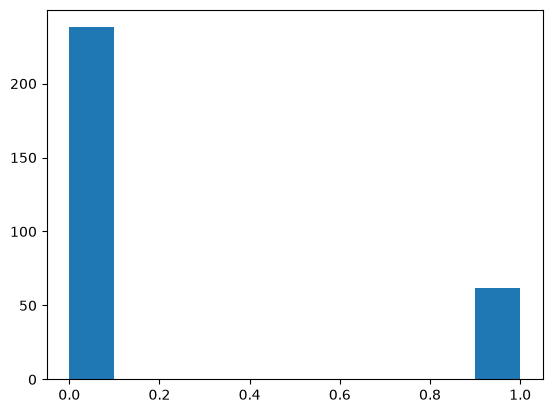

In [8]:
plt.hist(data["needs_service"])

(array([123.,   0.,   0.,  27.,   0.,   0.,  54.,   0.,   0.,  96.]),
 array([0. , 0.3, 0.6, 0.9, 1.2, 1.5, 1.8, 2.1, 2.4, 2.7, 3. ]),
 <BarContainer object of 10 artists>)

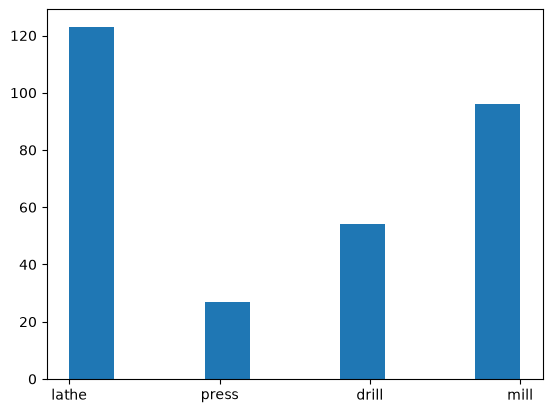

In [9]:
plt.hist(data["machine_type"])

In [10]:
data_new_a=data.copy()
data_new_a["temperature"]=data_new_a["temperature"].fillna(value=data_new_a["temperature"].median())
data_new_a.isna().sum()

machine_type      0
runtime_hours     0
temperature       0
vibration        23
pressure         16
needs_service     0
dtype: int64

In [11]:
data_new_b=data.copy()
data_new_b["temperature"]=data_new_b["temperature"].groupby(data_new_b["needs_service"]).transform(lambda x: x.mean)
data_new_b.isna().sum()

machine_type      0
runtime_hours     0
temperature       0
vibration        23
pressure         16
needs_service     0
dtype: int64

In [12]:
data_c=data_new_a.copy()
unique=data_c["machine_type"].unique()
print(unique)

<StringArray>
['lathe', 'press', 'drill', 'mill']
Length: 4, dtype: str


In [13]:
for i in unique:
    data_c[i] = (data_c["machine_type"] == i)

print(data_c["press"].sum())

27


In [14]:
def train_test_split(X,y,test_size=0.2,seed=42):
    np.random.seed(seed)
    n=len(y)
    train_index=[]
    test_index=[]
    for i in range(n):
        a=np.random.random()
        if a<test_size:
            test_index.append(i)
        else:
            train_index.append(i)
    X_train=[]
    X_test=[]
    y_train=[]
    y_test=[]
    for i in train_index:
        X_train.append(X.iloc[i,:])
        y_train.append(y[i])
    for i in test_index:
        X_test.append(X.iloc[i,:])
        y_test.append(y[i])
    return pd.DataFrame(X_train),pd.DataFrame(X_test),pd.DataFrame(y_train),pd.DataFrame(y_test)
    
    
    

In [20]:
X = data_c.iloc[:, :5]
y = data_c["needs_service"]
X.head(10)
X_train,X_test,y_train,y_test=train_test_split(X,y)


In [21]:
X_train.head()

,machine_type,runtime_hours,temperature,vibration,pressure
0,lathe,1837.7,60.23,1.61,3.96
1,lathe,560.1,90.55,3.96,3.12
2,press,551.5,65.58,1.29,5.04
3,drill,968.6,71.60,2.87,4.30
7,drill,2262.6,63.22,NaN,3.02


(array([98.,  0.,  0., 20.,  0.,  0., 46.,  0.,  0., 70.]),
 array([0. , 0.3, 0.6, 0.9, 1.2, 1.5, 1.8, 2.1, 2.4, 2.7, 3. ]),
 <BarContainer object of 10 artists>)

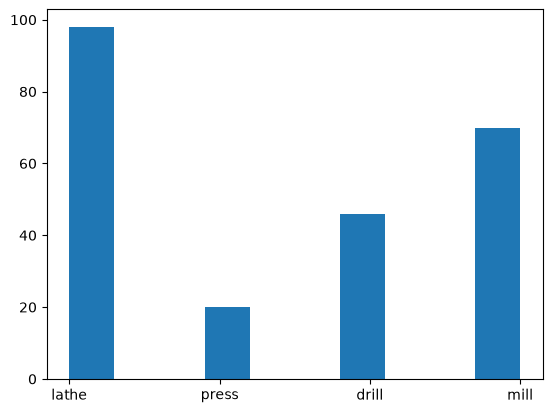

In [22]:
plt.hist(X_train["machine_type"])

In [ ]:
def predict(y_test):
    